# Notebook 2: Vehicle Classification with Deep Learning
# Dataset: VehicleClassifier from HuggingFace

### 1. Import Libraries

In [1]:
# 1. Install the required interactive widget package
!pip install -q ipympl

# 2. Enable widget support for Google Colab if applicable
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

# 3. Now the widget backend will load properly
import warnings
warnings.filterwarnings('ignore')
try:
    %matplotlib widget
    print("Widget backend enabled successfully")
except Exception as e:
    print(f"Widget backend failed: {e}")
    try:
        %matplotlib notebook
        print("Notebook backend enabled as fallback")
    except:
        %matplotlib inline
        print("Inline backend enabled as final fallback")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.8 MB/s eta 0:00:00
Widget backend failed: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']
Inline backend enabled as final fallback


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

### 2. Data Preparation

In [3]:
# Load dataset
dataset = load_dataset("infinite-dataset-hub/VehicleClassifier")
df = pd.DataFrame(dataset['train'])

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'])
class_names = le.classes_
n_classes = len(class_names)

# Text vectorization
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X = tfidf.fit_transform(df['description'].fillna('')).toarray()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert to PyTorch tensors
X_train_torch = torch.FloatTensor(X_train)
y_train_torch = torch.LongTensor(y_train)
X_test_torch = torch.FloatTensor(X_test)
y_test_torch = torch.LongTensor(y_test)

# Create data loaders
batch_size = 16
train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

README.md:   0%|          | 0.00/2.36k [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/11.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

### 3. PyTorch - Simple Neural Network

Training PyTorch Neural Network...
Epoch [10/50], Loss: 2.2790, Test Acc: 0.1000
Epoch [20/50], Loss: 1.8270, Test Acc: 0.1500
Epoch [30/50], Loss: 0.9242, Test Acc: 0.4500
Epoch [40/50], Loss: 0.3346, Test Acc: 0.5500
Epoch [50/50], Loss: 0.1501, Test Acc: 0.6500


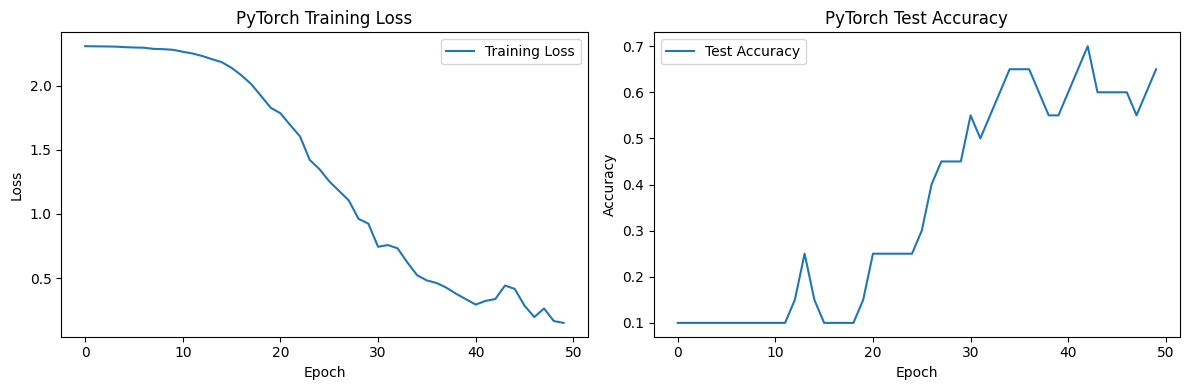

In [4]:
class PyTorchClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.layers = nn.ModuleList()
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            self.layers.append(nn.Linear(prev_dim, hidden_dim))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim
        self.layers.append(nn.Linear(prev_dim, output_dim))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Initialize model
input_dim = X_train.shape[1]
hidden_dims = [128, 64, 32]
model = PyTorchClassifier(input_dim, hidden_dims, n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_model_pytorch(model, train_loader, test_loader, epochs=50):
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # Testing
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()

        test_accuracies.append(correct / total)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}')

    return train_losses, test_accuracies

# Train PyTorch model
print("Training PyTorch Neural Network...")
train_losses, test_accuracies = train_model_pytorch(model, train_loader, test_loader, epochs=50)

# Plot training progress
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('PyTorch Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('PyTorch Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### 4. TensorFlow/Keras - Sequential Model

Training TensorFlow Sequential Model...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - accuracy: 0.1375 - loss: 2.3011 - val_accuracy: 0.3000 - val_loss: 2.2970
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.1125 - loss: 2.2979 - val_accuracy: 0.2500 - val_loss: 2.2937
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.1000 - loss: 2.2936 - val_accuracy: 0.2000 - val_loss: 2.2900
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.1500 - loss: 2.2805 - val_accuracy: 0.1500 - val_loss: 2.2871
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2875 - loss: 2.2693 - val_accuracy: 0.2000 - val_loss: 2.2834
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3625 - loss: 2.2573 - val_accuracy: 0.2000 - val_loss: 2.2791
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3375 - loss: 2.2381 - val_accuracy: 0.3000 - val_loss: 2.2741
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4125 - loss: 2.226

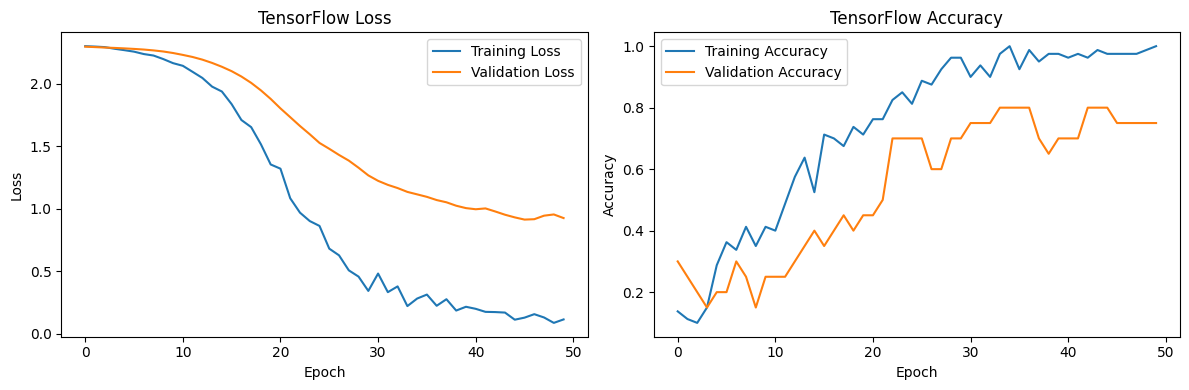

In [5]:
# Build TensorFlow model
tf_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(n_classes, activation='softmax')
])

tf_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Train TensorFlow model
print("Training TensorFlow Sequential Model...")
history = tf_model.fit(X_train, y_train,
                       epochs=50,
                       batch_size=16,
                       validation_data=(X_test, y_test),
                       verbose=1)

# Plot TensorFlow training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('TensorFlow Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('TensorFlow Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


### 5. Model Comparison and Visualization

In [6]:
# Evaluate both models
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_pytorch = torch.argmax(model(X_test_torch), dim=1).numpy()
y_pred_tf = np.argmax(tf_model.predict(X_test), axis=1)

pytorch_acc = accuracy_score(y_test, y_pred_pytorch)
tf_acc = accuracy_score(y_test, y_pred_tf)

print(f"PyTorch Model Accuracy: {pytorch_acc:.4f}")
print(f"TensorFlow Model Accuracy: {tf_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
PyTorch Model Accuracy: 0.6500
TensorFlow Model Accuracy: 0.7500


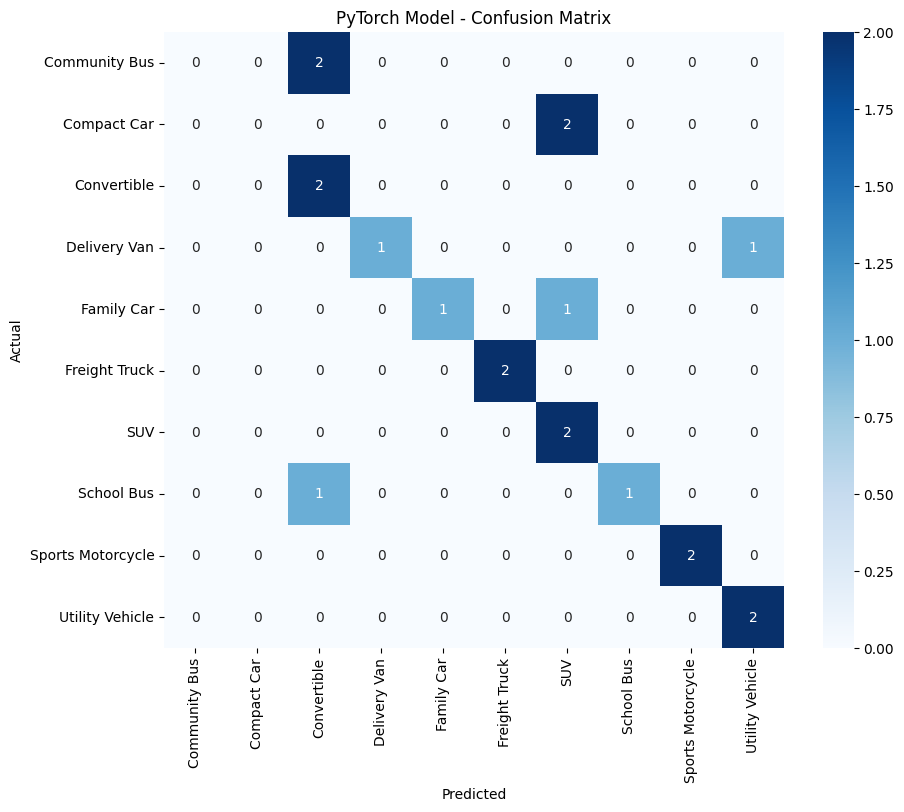

In [7]:
# Confusion Matrix for PyTorch model
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_pytorch)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('PyTorch Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


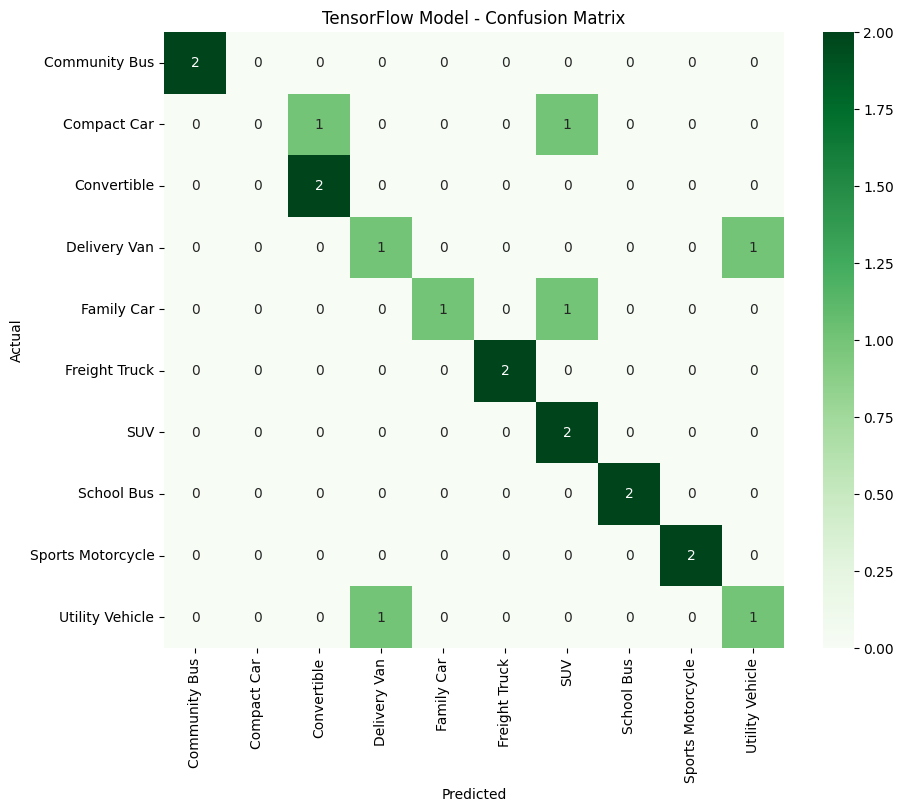

In [8]:

# Confusion Matrix for TensorFlow model
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_tf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('TensorFlow Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 5. Bokeh 3D Surface for Model Predictions

In [9]:
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
output_notebook()

# Use PCA to reduce to 2D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Train a simple model on PCA components for visualization
from sklearn.ensemble import RandomForestClassifier
vis_model = RandomForestClassifier(n_estimators=50, random_state=42)
vis_model.fit(X_pca, y_train)

# Create meshgrid for surface
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                     np.linspace(y_min, y_max, 30))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
zz = vis_model.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# Bokeh surface plot
from bokeh.models import ColorBar
p = figure(title="Decision Surface (Deep Learning vs Classical)",
           width=600, height=500, x_axis_label='PC1', y_axis_label='PC2')

# Create color mapper
mapper = LinearColorMapper(palette="Viridis256", low=zz.min(), high=zz.max())

# Image plot
p.image(image=[zz], x=xx.min(), y=yy.min(), dw=xx.max()-xx.min(),
        dh=yy.max()-yy.min(), color_mapper=mapper, alpha=0.6)

# Add scatter points
source = ColumnDataSource(data=dict(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    labels=[class_names[i] for i in y_train]
))
p.scatter('x', 'y', source=source, size=8, color='red', alpha=0.5)

# Add color bar
color_bar = ColorBar(color_mapper=mapper, width=8, location=(0,0))
p.add_layout(color_bar, 'right')
show(p)